# Figure S5 - mutation homoplasy and background distance

This notebook reproduces the three supplementary mutation-homoplasy figures **inline**, using the exact same functions and data as the command-line scripts (`scripts/mutation_background_distances.py` and `scripts/plot_mutation_homoplasy.py`): it calls `compute_tables` to build the tables and the `build_*` figure functions to draw them, so nothing is duplicated. Each figure is followed by a caption explaining the axes, what a point means, and how the values were computed. See `specs/mutation_homoplasy.md` for the full method write-up.

## Package imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

%matplotlib inline

HERE = Path.cwd()
sys.path.append(str(HERE.parent / 'scripts'))

from mutation_background_distances import compute_tables
from plot_mutation_homoplasy import (
    RC_PARAMS,
    build_antigenic_figure,
    build_figure,
    build_occurrence_figure,
)

## Build the tables (identical data to the scripts)

In [2]:
build = 'flu-final'
data = HERE.parent / 'data' / build
epitope_sites = (
    HERE.parent.parent
    / 'antigen-prime' / 'src' / 'main' / 'resources' / 'epitopeSites.txt'
)

tables = compute_tables(
    auspice_json=data / 'variant-assignment' / 'phylogenetic' / 'auspice.json',
    sequences_fasta=data / 'antigen-outputs' / 'unique_sequences.fasta',
    ref_genbank=data / 'auspice' / 'ref_HA.gb',
    epitope_sites_path=epitope_sites,
    tips_csv=data / 'antigen-outputs' / 'unique_tips.csv',
    anchor_tip='45b125db',
    min_origin_progeny=1,
    max_carriers=1500,
    null_samples=20000,
    seed=0,
)
mutations = tables['mutations']
background_null = tables['background_null']
pairs = tables['pairs']
antigenic_null = tables['antigenic_null']
len(mutations), len(pairs)

  epitope: 325 unique AA mutations (182 with >=2 independent origins).
  non-epitope: 1511 unique AA mutations (592 with >=2 independent origins).


(1836, 2434)

## Figure S5a - background distance between independent origins

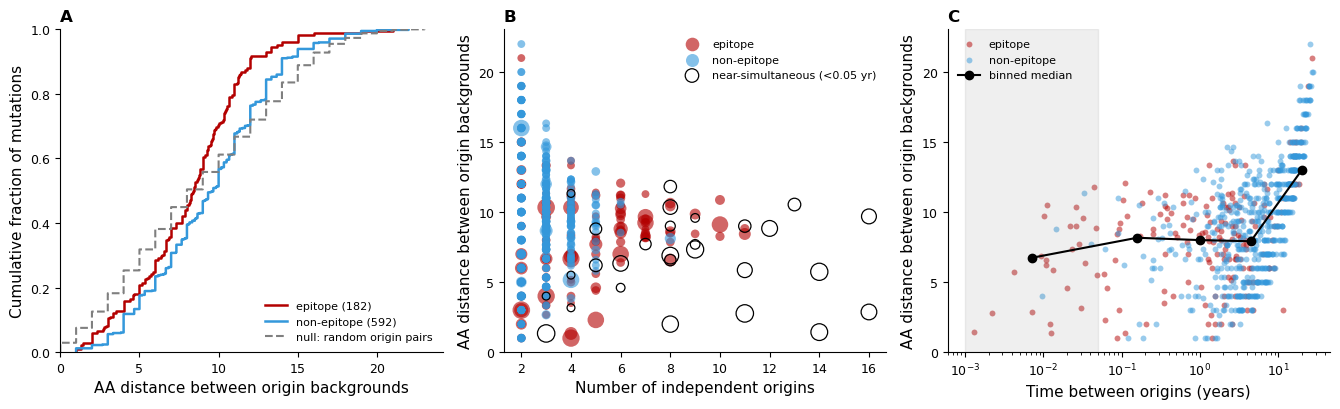

In [3]:
with plt.rc_context(RC_PARAMS):
    fig = build_figure(mutations, background_null)
plt.show()

**Figure S5a.** How genetically different are the backgrounds in which the *same* amino-acid mutation independently arises? Only recurrent mutations (>=2 independent origins on the inferred tree) appear. **Panel A** is the cumulative distribution (ECDF) of the mean pairwise amino-acid Hamming distance between a mutation's origin *backgrounds* (each origin's parent-node reconstructed HA1+HA2 sequence), drawn separately for epitope and non-epitope mutations against a null of distances between random pairs of origin backgrounds; a curve lying on the null means those origins are no closer than two arbitrary origins. **Panel B** places each recurrent mutation at its number of independent origins (x) versus mean background distance (y), sized by log of its largest descendant clade; open circles mark near-simultaneous origins (dated <0.05 yr apart), the signature of one real event split across nearby branches by tree inference. **Panel C** plots background distance against the time separating a mutation's origins (log x) with a binned median line: the more separated in time two origins are, the more genetically distinct the backgrounds they arise in.

## Figure S5b - independent-origin count distribution

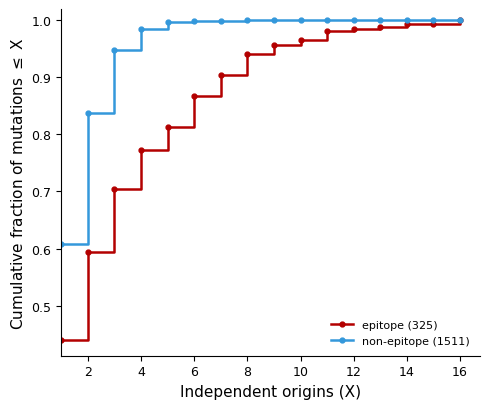

In [4]:
with plt.rc_context(RC_PARAMS):
    fig = build_occurrence_figure(mutations)
plt.show()

**Figure S5b.** Cumulative fraction of amino-acid mutations arising at most X times independently on the inferred tree, split by site class. X starts at 1, so the height at X=1 is the fraction of single-origin mutations. A lower, right-shifted curve means more recurrence: epitope mutations recur more than non-epitope ones. Each mutation's origin count is the number of tree branches carrying that (gene, position, from->to) substitution.

## Figure S5c - antigenic vs genetic distance between origins

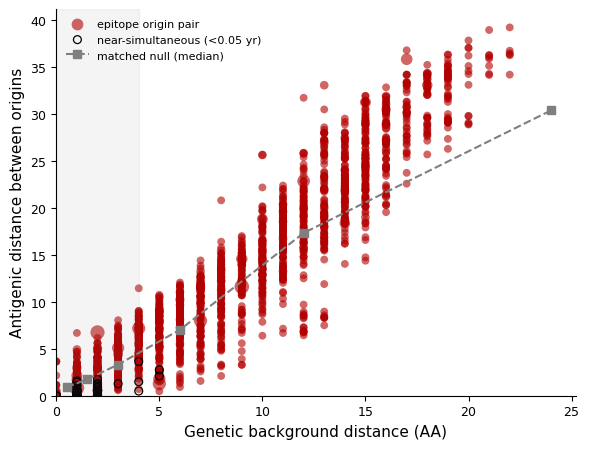

In [5]:
with plt.rc_context(RC_PARAMS):
    fig = build_antigenic_figure(pairs, antigenic_null)
plt.show()

**Figure S5c.** Do independent origins of the *same* epitope mutation land in the same antigenic place? Each point is one pair of independent origins of a single epitope mutation: x is the amino-acid Hamming distance between the two origins' backgrounds, y is the Euclidean distance between the two origins' antigenic positions. An origin's antigenic position is the mean `(ag1, ag2)` of its minimal-epitope-count descendant tips, which added no further epitope mutation and so sit at the origin's exact post-mutation antigenic phenotype. Because antigenic position drifts with cumulative epitope count, antigenic distance is only interpretable relative to background distance: the dashed line is the matched null (median antigenic distance of random epitope-origin pairs, binned by background distance). Same-mutation pairs track the null, so there is no antigenic convergence beyond what background similarity already implies. Open circles are near-simultaneous origins (<0.05 yr apart); they sit at ~0 antigenic distance, confirming they are single events split by tree inference rather than true recurrences. The shaded band marks the similar-background regime the reviewer's concern targets.